# LAB 06 — Map Coloring CSP

## Performance Comparison of DFS-Backtracking and Local Search

### Algorithms
1. DFS-Backtracking with MRV, LCV and Forward Checking
2. Local Search with Min-Conflicts

### Objective
To experimentally compare the performance of both algorithms
as the number of variables and constraints increases.

In [24]:
import random
import time
import statistics
import matplotlib.pyplot as plt

# Exactly three colors as required by the assignment
COLORS = ["Red", "Green", "Blue"]

# Required test cases
TEST_SIZES = [3, 5, 7, 10, 15, 20, 30, 40, 50]

# Number of runs for each algorithm
NUM_RUNS = 10

# Maximum iterations for Local Search
MAX_ITERATIONS = 10000

print("Colors:", COLORS)
print("Test sizes:", TEST_SIZES)
print("Runs per algorithm:", NUM_RUNS)
print("Maximum Local Search iterations:", MAX_ITERATIONS)

Colors: ['Red', 'Green', 'Blue']
Test sizes: [3, 5, 7, 10, 15, 20, 30, 40, 50]
Runs per algorithm: 10
Maximum Local Search iterations: 10000


In [25]:
def region_name(index):
    """
    Convert an integer index into a readable region name.

    0  -> A
    1  -> B
    ...
    25 -> Z
    26 -> AA
    27 -> AB
    """
    name = ""

    index += 1

    while index > 0:
        index -= 1
        name = chr(65 + (index % 26)) + name
        index //= 26

    return name

In [26]:
def generate_graph(n, edge_probability=0.07, seed=None):
    """
    Generate a guaranteed 3-colorable graph.

    A hidden 3-coloring is first generated.
    Edges are only created between vertices having
    different hidden colors.

    Therefore, the hidden coloring is guaranteed to
    be a valid 3-coloring.
    """

    rng = random.Random(seed)

    # Hidden valid coloring
    planted_colors = {
        v: rng.randrange(3)
        for v in range(n)
    }

    edges = set()

    # Generate edges only between differently colored vertices
    for u in range(n):
        for v in range(u + 1, n):

            if planted_colors[u] != planted_colors[v]:

                if rng.random() < edge_probability:
                    edges.add((u, v))

    # Make sure every region has at least one connection
    for u in range(n):

        has_edge = any(u in edge for edge in edges)

        if not has_edge:

            possible = [
                v for v in range(n)
                if v != u and planted_colors[v] != planted_colors[u]
            ]

            if possible:
                v = rng.choice(possible)
                edges.add(tuple(sorted((u, v))))

    # Build adjacency list
    adjacency = {
        v: set()
        for v in range(n)
    }

    for u, v in edges:
        adjacency[u].add(v)
        adjacency[v].add(u)

    return adjacency, edges, planted_colors

In [27]:
def count_constraints(edges):
    """
    Number of constraints = number of unique edges.
    """
    return len(edges)


def check_coloring(adjacency, coloring):
    """
    Check whether a complete coloring satisfies
    every constraint.
    """

    for u in adjacency:

        for v in adjacency[u]:

            if u < v:

                if coloring[u] == coloring[v]:
                    return False

    return True


def count_conflicts(adjacency, coloring):
    """
    Count the number of violated constraints.
    Each edge is counted only once.
    """

    conflicts = 0

    for u in adjacency:

        for v in adjacency[u]:

            if u < v and coloring[u] == coloring[v]:
                conflicts += 1

    return conflicts

In [28]:
n = 5

adjacency, edges, planted = generate_graph(
    n,
    edge_probability=0.07,
    seed=100
)

print("Number of Variables:", n)
print("Number of Constraints:", len(edges))
print()

print("Edges:")

for u, v in sorted(edges):
    print(f"{region_name(u)} - {region_name(v)}")

print()

print("Hidden valid coloring:")

for v in range(n):
    print(
        f"{region_name(v)} -> {COLORS[planted[v]]}"
    )

# Verify that the planted coloring is valid
valid = check_coloring(adjacency, planted)

print()
print("Graph is 3-colorable:", valid)

Number of Variables: 5
Number of Constraints: 3

Edges:
A - B
A - E
C - D

Hidden valid coloring:
A -> Red
B -> Green
C -> Green
D -> Red
E -> Blue

Graph is 3-colorable: True


In [29]:
def dfs_backtracking(adjacency):
    """
    DFS-Backtracking CSP solver using:
    - MRV
    - LCV
    - Forward Checking

    Returns:
        solution_found
        final_coloring
        statistics
    """

    n = len(adjacency)

    # Initially every variable has all 3 colors
    domains = {
        v: set(range(3))
        for v in range(n)
    }

    assignment = {}

    stats = {
        "assignments": 0,
        "backtracks": 0
    }

    def is_consistent(variable, color):

        for neighbor in adjacency[variable]:

            if neighbor in assignment:

                if assignment[neighbor] == color:
                    return False

        return True

    def select_mrv_variable():

        unassigned = [
            v for v in range(n)
            if v not in assignment
        ]

        # MRV:
        # choose the variable with the fewest legal values
        best_variable = None
        best_count = float("inf")

        for v in unassigned:

            legal_count = sum(
                1
                for color in domains[v]
                if is_consistent(v, color)
            )

            if legal_count < best_count:
                best_count = legal_count
                best_variable = v

        return best_variable

    def order_lcv_values(variable):

        values = []

        for color in domains[variable]:

            eliminated = 0

            # LCV:
            # count how many choices this color removes
            # from neighboring unassigned variables

            for neighbor in adjacency[variable]:

                if neighbor not in assignment:

                    if color in domains[neighbor]:
                        eliminated += 1

            values.append((eliminated, color))

        # Least Constraining Value
        values.sort(key=lambda x: x[0])

        return [color for _, color in values]

    def forward_check(variable, color, current_domains):

        new_domains = {
            v: set(current_domains[v])
            for v in current_domains
        }

        # Assigned variable gets only its selected color
        new_domains[variable] = {color}

        for neighbor in adjacency[variable]:

            if neighbor not in assignment:

                # Remove selected color
                # from neighbor's domain
                new_domains[neighbor].discard(color)

                # Empty domain means failure
                if len(new_domains[neighbor]) == 0:
                    return None

        return new_domains

    def backtrack():

        # All variables assigned
        if len(assignment) == n:
            return True

        # MRV
        variable = select_mrv_variable()

        # LCV
        ordered_values = order_lcv_values(variable)

        for color in ordered_values:

            if not is_consistent(variable, color):
                continue

            stats["assignments"] += 1

            # Assign color
            assignment[variable] = color

            # Forward Checking
            new_domains = forward_check(
                variable,
                color,
                domains
            )

            if new_domains is not None:

                old_domains = {
                    v: set(domains[v])
                    for v in domains
                }

                # Update domains
                for v in domains:
                    domains[v] = new_domains[v]

                # Continue DFS
                if backtrack():
                    return True

                # Restore domains
                for v in domains:
                    domains[v] = old_domains[v]

            # Undo assignment
            del assignment[variable]

            # Count backtrack
            stats["backtracks"] += 1

        return False

    solution_found = backtrack()

    return (
        solution_found,
        assignment.copy(),
        stats
    )

In [30]:
n = 5

adjacency, edges, planted = generate_graph(
    n,
    edge_probability=0.07,
    seed=100
)

start = time.perf_counter()

solution_found, coloring, dfs_stats = dfs_backtracking(
    adjacency
)

end = time.perf_counter()

execution_time = (end - start) * 1000

print("DFS-BACKTRACKING")
print("----------------")
print("Solution Found:", "Yes" if solution_found else "No")
print(f"Execution Time: {execution_time:.4f} ms")
print("Assignments:", dfs_stats["assignments"])
print("Backtracks:", dfs_stats["backtracks"])

print()
print("Final Coloring:")

for v in sorted(coloring):
    print(
        f"{region_name(v)} -> {COLORS[coloring[v]]}"
    )

DFS-BACKTRACKING
----------------
Solution Found: Yes
Execution Time: 0.1856 ms
Assignments: 5
Backtracks: 0

Final Coloring:
A -> Red
B -> Green
C -> Red
D -> Green
E -> Green


In [31]:
def min_conflicts(adjacency, max_iterations=10000, seed=None):
    """
    Local Search using Min-Conflicts.
    """

    rng = random.Random(seed)

    n = len(adjacency)

    # Step 1:
    # Generate a random COMPLETE coloring
    coloring = {
        v: rng.randrange(3)
        for v in range(n)
    }

    def variable_conflicts(variable, color):

        conflicts = 0

        for neighbor in adjacency[variable]:

            if coloring[neighbor] == color:
                conflicts += 1

        return conflicts

    def get_conflicted_variables():

        conflicted = []

        for v in range(n):

            if variable_conflicts(
                v,
                coloring[v]
            ) > 0:

                conflicted.append(v)

        return conflicted

    # Step 2-5
    for iteration in range(max_iterations + 1):

        current_conflicts = count_conflicts(
            adjacency,
            coloring
        )

        # Zero conflicts = solution
        if current_conflicts == 0:

            return (
                True,
                coloring.copy(),
                {
                    "iterations": iteration,
                    "conflicts": 0
                }
            )

        # Find conflicted variables
        conflicted_variables = get_conflicted_variables()

        if not conflicted_variables:
            break

        # Select a random conflicted variable
        variable = rng.choice(
            conflicted_variables
        )

        # Try all 3 colors
        conflict_counts = {}

        for color in range(3):

            conflict_counts[color] = variable_conflicts(
                variable,
                color
            )

        minimum = min(
            conflict_counts.values()
        )

        # Colors having minimum conflicts
        best_colors = [
            color
            for color, conflicts in conflict_counts.items()
            if conflicts == minimum
        ]

        # Random tie-breaking
        selected_color = rng.choice(
            best_colors
        )

        # Change variable's color
        coloring[variable] = selected_color

    # Maximum iterations reached
    final_conflicts = count_conflicts(
        adjacency,
        coloring
    )

    return (
        False,
        coloring.copy(),
        {
            "iterations": max_iterations,
            "conflicts": final_conflicts
        }
    )

In [32]:
n = 5

adjacency, edges, planted = generate_graph(
    n,
    edge_probability=0.07,
    seed=100
)

start = time.perf_counter()

solution_found, coloring, ls_stats = min_conflicts(
    adjacency,
    max_iterations=MAX_ITERATIONS,
    seed=123
)

end = time.perf_counter()

execution_time = (end - start) * 1000

print("LOCAL SEARCH")
print("------------")
print("Solution Found:", "Yes" if solution_found else "No")
print(f"Execution Time: {execution_time:.4f} ms")
print("Iterations:", ls_stats["iterations"])
print("Conflicts:", ls_stats["conflicts"])

print()
print("Final Coloring:")

for v in sorted(coloring):
    print(
        f"{region_name(v)} -> {COLORS[coloring[v]]}"
    )

LOCAL SEARCH
------------
Solution Found: Yes
Execution Time: 0.1059 ms
Iterations: 0
Conflicts: 0

Final Coloring:
A -> Red
B -> Green
C -> Red
D -> Green
E -> Green


In [33]:
def run_experiment_for_graph(
    adjacency,
    edges,
    num_runs=10
):
    """
    Run DFS and Local Search 10 times
    on the SAME graph.
    """

    dfs_times = []
    dfs_assignments = []
    dfs_backtracks = []
    dfs_solutions = []

    ls_times = []
    ls_iterations = []
    ls_conflicts = []
    ls_solutions = []

    final_dfs_coloring = None
    final_ls_coloring = None

    # -------------------------------------------------
    # DFS: 10 runs
    # -------------------------------------------------

    for run in range(num_runs):

        start = time.perf_counter()

        found, coloring, stats = dfs_backtracking(
            adjacency
        )

        end = time.perf_counter()

        elapsed_ms = (end - start) * 1000

        dfs_times.append(elapsed_ms)
        dfs_assignments.append(
            stats["assignments"]
        )
        dfs_backtracks.append(
            stats["backtracks"]
        )
        dfs_solutions.append(found)

        if found:
            final_dfs_coloring = coloring

    # -------------------------------------------------
    # Local Search: 10 runs
    # -------------------------------------------------

    for run in range(num_runs):

        start = time.perf_counter()

        found, coloring, stats = min_conflicts(
            adjacency,
            max_iterations=MAX_ITERATIONS,
            seed=10000 + run
        )

        end = time.perf_counter()

        elapsed_ms = (end - start) * 1000

        ls_times.append(elapsed_ms)
        ls_iterations.append(
            stats["iterations"]
        )
        ls_conflicts.append(
            stats["conflicts"]
        )
        ls_solutions.append(found)

        if found and final_ls_coloring is None:
            final_ls_coloring = coloring

    return {
        "constraints": len(edges),

        "dfs_avg_time": statistics.mean(dfs_times),
        "dfs_avg_assignments": statistics.mean(
            dfs_assignments
        ),
        "dfs_avg_backtracks": statistics.mean(
            dfs_backtracks
        ),
        "dfs_solutions": sum(dfs_solutions),

        "ls_avg_time": statistics.mean(ls_times),
        "ls_avg_iterations": statistics.mean(
            ls_iterations
        ),
        "ls_avg_conflicts": statistics.mean(
            ls_conflicts
        ),
        "ls_solutions": sum(ls_solutions),

        "dfs_coloring": final_dfs_coloring,
        "ls_coloring": final_ls_coloring
    }

In [34]:
results = []

for test_number, n in enumerate(TEST_SIZES, start=1):

    print("=" * 60)
    print(f"Test Case: {test_number}")
    print("=" * 60)

    # Generate ONE graph
    adjacency, edges, planted = generate_graph(
        n,
        edge_probability=0.07,
        seed=5000 + n
    )

    # Verify 3-colorability
    assert check_coloring(
        adjacency,
        planted
    ), "Generated graph is not 3-colorable!"

    # Run both algorithms on SAME graph
    experiment = run_experiment_for_graph(
        adjacency,
        edges,
        NUM_RUNS
    )

    result = {
        "variables": n,
        "constraints": experiment["constraints"],

        "dfs_time": experiment["dfs_avg_time"],
        "local_time": experiment["ls_avg_time"],

        "dfs_assignments": experiment[
            "dfs_avg_assignments"
        ],

        "dfs_backtracks": experiment[
            "dfs_avg_backtracks"
        ],

        "local_iterations": experiment[
            "ls_avg_iterations"
        ],

        "local_conflicts": experiment[
            "ls_avg_conflicts"
        ],

        "dfs_solutions": experiment[
            "dfs_solutions"
        ],

        "local_solutions": experiment[
            "ls_solutions"
        ],

        "dfs_coloring": experiment[
            "dfs_coloring"
        ],

        "local_coloring": experiment[
            "ls_coloring"
        ]
    }

    results.append(result)

    print("Variables:", n)
    print("Constraints:", experiment["constraints"])

    print()
    print("DFS-Backtracking")
    print(
        f"Average Time: "
        f"{experiment['dfs_avg_time']:.4f} ms"
    )
    print(
        f"Average Assignments: "
        f"{experiment['dfs_avg_assignments']:.2f}"
    )
    print(
        f"Average Backtracks: "
        f"{experiment['dfs_avg_backtracks']:.2f}"
    )
    print(
        f"Solutions Found: "
        f"{experiment['dfs_solutions']}/{NUM_RUNS}"
    )

    print()
    print("Local Search")
    print(
        f"Average Time: "
        f"{experiment['ls_avg_time']:.4f} ms"
    )
    print(
        f"Average Iterations: "
        f"{experiment['ls_avg_iterations']:.2f}"
    )
    print(
        f"Average Conflicts: "
        f"{experiment['ls_avg_conflicts']:.2f}"
    )
    print(
        f"Solutions Found: "
        f"{experiment['ls_solutions']}/{NUM_RUNS}"
    )

    print()

Test Case: 1
Variables: 3
Constraints: 2

DFS-Backtracking
Average Time: 0.0336 ms
Average Assignments: 3.00
Average Backtracks: 0.00
Solutions Found: 10/10

Local Search
Average Time: 0.0185 ms
Average Iterations: 0.60
Average Conflicts: 0.00
Solutions Found: 10/10

Test Case: 2
Variables: 5
Constraints: 4

DFS-Backtracking
Average Time: 0.0520 ms
Average Assignments: 5.00
Average Backtracks: 0.00
Solutions Found: 10/10

Local Search
Average Time: 0.0236 ms
Average Iterations: 1.60
Average Conflicts: 0.00
Solutions Found: 10/10

Test Case: 3
Variables: 7
Constraints: 4

DFS-Backtracking
Average Time: 0.0832 ms
Average Assignments: 7.00
Average Backtracks: 0.00
Solutions Found: 10/10

Local Search
Average Time: 0.0231 ms
Average Iterations: 1.10
Average Conflicts: 0.00
Solutions Found: 10/10

Test Case: 4
Variables: 10
Constraints: 7

DFS-Backtracking
Average Time: 0.2160 ms
Average Assignments: 10.00
Average Backtracks: 0.00
Solutions Found: 10/10

Local Search
Average Time: 0.0571 ms

In [35]:
print(
    f"{'Variables':<10}"
    f"{'Constraints':<13}"
    f"{'DFS Time(ms)':<15}"
    f"{'Local Time(ms)':<17}"
    f"{'Assignments':<13}"
    f"{'Backtracks':<13}"
    f"{'Iterations':<13}"
    f"{'DFS Sol.':<10}"
    f"{'LS Sol.':<10}"
)

print("-" * 125)

for r in results:

    print(
        f"{r['variables']:<10}"
        f"{r['constraints']:<13}"
        f"{r['dfs_time']:<15.4f}"
        f"{r['local_time']:<17.4f}"
        f"{r['dfs_assignments']:<13.2f}"
        f"{r['dfs_backtracks']:<13.2f}"
        f"{r['local_iterations']:<13.2f}"
        f"{r['dfs_solutions']}/10"
        f"{'':<5}"
        f"{r['local_solutions']}/10"
    )

Variables Constraints  DFS Time(ms)   Local Time(ms)   Assignments  Backtracks   Iterations   DFS Sol.  LS Sol.   
-----------------------------------------------------------------------------------------------------------------------------
3         2            0.0336         0.0185           3.00         0.00         0.60         10/10     10/10
5         4            0.0520         0.0236           5.00         0.00         1.60         10/10     10/10
7         4            0.0832         0.0231           7.00         0.00         1.10         10/10     10/10
10        7            0.2160         0.0571           10.00        0.00         2.40         10/10     10/10
15        12           0.4598         0.0722           15.00        0.00         3.80         10/10     10/10
20        17           0.5537         0.1071           20.00        0.00         6.30         10/10     10/10
30        28           1.2354         0.2347           30.00        0.00         10.50        10/10

In [36]:
# Display the final coloring for the largest test case

largest = results[-1]

print("=" * 60)
print("FINAL COLORING — DFS")
print("=" * 60)

if largest["dfs_coloring"] is not None:

    for v in sorted(largest["dfs_coloring"]):
        print(
            f"{region_name(v)} -> "
            f"{COLORS[largest['dfs_coloring'][v]]}"
        )

else:
    print("No DFS solution found.")


print()
print("=" * 60)
print("FINAL COLORING — LOCAL SEARCH")
print("=" * 60)

if largest["local_coloring"] is not None:

    for v in sorted(largest["local_coloring"]):
        print(
            f"{region_name(v)} -> "
            f"{COLORS[largest['local_coloring'][v]]}"
        )

else:
    print("No Local Search solution found.")

FINAL COLORING — DFS
A -> Red
B -> Green
C -> Green
D -> Green
E -> Red
F -> Red
G -> Green
H -> Blue
I -> Blue
J -> Red
K -> Red
L -> Red
M -> Red
N -> Red
O -> Green
P -> Red
Q -> Green
R -> Red
S -> Red
T -> Red
U -> Red
V -> Green
W -> Blue
X -> Red
Y -> Red
Z -> Red
AA -> Red
AB -> Red
AC -> Green
AD -> Red
AE -> Green
AF -> Green
AG -> Green
AH -> Red
AI -> Green
AJ -> Red
AK -> Red
AL -> Blue
AM -> Green
AN -> Red
AO -> Green
AP -> Green
AQ -> Blue
AR -> Green
AS -> Green
AT -> Green
AU -> Blue
AV -> Blue
AW -> Green
AX -> Red

FINAL COLORING — LOCAL SEARCH
A -> Green
B -> Green
C -> Blue
D -> Blue
E -> Red
F -> Blue
G -> Red
H -> Green
I -> Blue
J -> Red
K -> Red
L -> Blue
M -> Green
N -> Red
O -> Green
P -> Blue
Q -> Blue
R -> Green
S -> Red
T -> Green
U -> Green
V -> Red
W -> Green
X -> Red
Y -> Blue
Z -> Blue
AA -> Blue
AB -> Green
AC -> Red
AD -> Red
AE -> Red
AF -> Blue
AG -> Red
AH -> Blue
AI -> Red
AJ -> Green
AK -> Red
AL -> Green
AM -> Blue
AN -> Blue
AO -> Green
AP ->

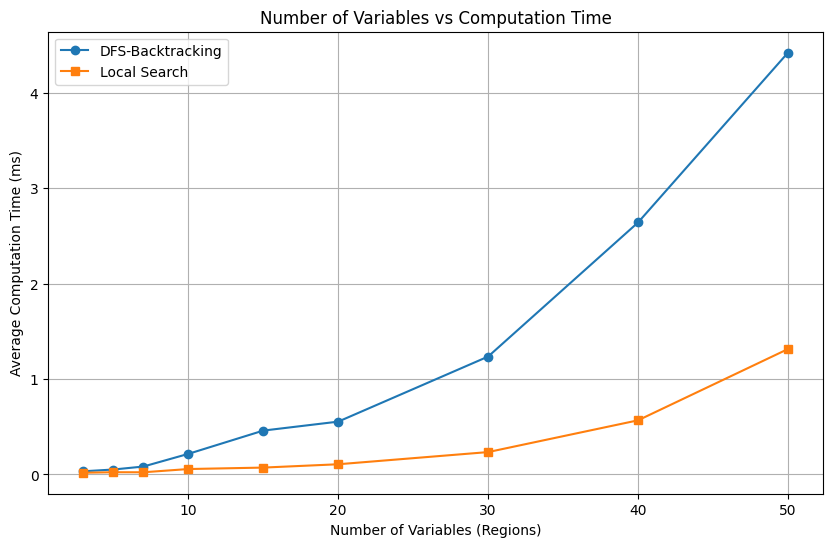

In [37]:
variables = [
    r["variables"]
    for r in results
]

dfs_times = [
    r["dfs_time"]
    for r in results
]

local_times = [
    r["local_time"]
    for r in results
]

plt.figure(figsize=(10, 6))

plt.plot(
    variables,
    dfs_times,
    marker="o",
    label="DFS-Backtracking"
)

plt.plot(
    variables,
    local_times,
    marker="s",
    label="Local Search"
)

plt.xlabel("Number of Variables (Regions)")
plt.ylabel("Average Computation Time (ms)")
plt.title("Number of Variables vs Computation Time")

plt.legend()
plt.grid(True)

plt.show()

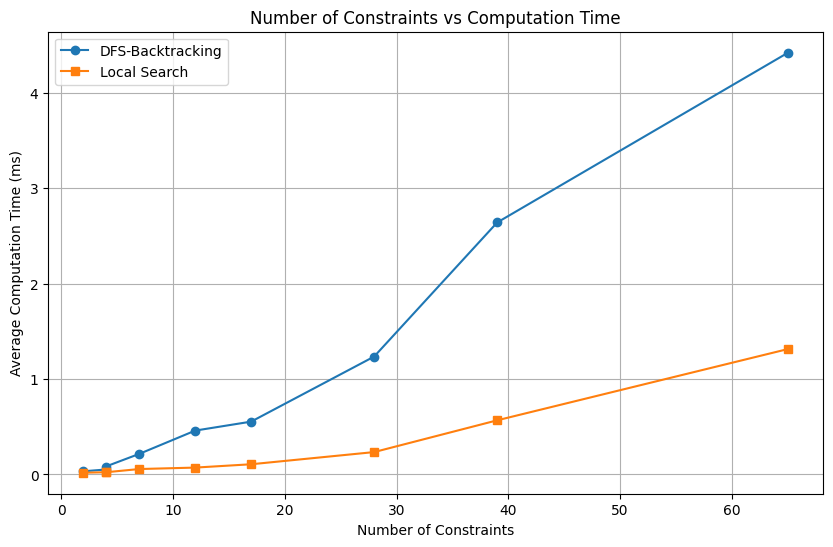

In [38]:
constraints = [
    r["constraints"]
    for r in results
]

plt.figure(figsize=(10, 6))

plt.plot(
    constraints,
    dfs_times,
    marker="o",
    label="DFS-Backtracking"
)

plt.plot(
    constraints,
    local_times,
    marker="s",
    label="Local Search"
)

plt.xlabel("Number of Constraints")
plt.ylabel("Average Computation Time (ms)")
plt.title("Number of Constraints vs Computation Time")

plt.legend()
plt.grid(True)

plt.show()

# Part G — Analysis and Discussion

## 1. Which algorithm performs better for small CSPs?

Based on the experimental results, Local Search with Min-Conflicts performs better for the small CSPs tested. For example, for 3 variables, DFS-Backtracking takes 0.0336 ms on average, while Local Search takes 0.0185 ms.

## 2. Which algorithm performs better as the number of variables increases?

As the number of variables increases, Local Search continues to perform better in the experiment. At 50 variables, DFS-Backtracking takes 4.4184 ms on average, while Local Search takes 1.3140 ms.

## 3. How does increasing the number of constraints affect DFS-Backtracking?

Increasing the number of constraints generally increases the amount of constraint checking required by DFS-Backtracking. In the experiment, the execution time increased as the problem became larger and more constrained. However, the generated instances were relatively easy, so the average number of backtracks remained 0.00.

## 4. How does increasing the number of constraints affect Local Search?

More constraints can increase the number of conflicts that Local Search has to resolve. In this experiment, the number of constraints generally increased with problem size, and the average number of iterations also increased overall. The reported final conflicts were 0.00 because successful runs ended with valid colorings.

## 5. How does the number of backtracks change as the problem size increases?

The average number of backtracks remained 0.00 for all tested problem sizes. This indicates that the generated graphs were relatively easy for the DFS solver and did not require backtracking in these particular instances.

## 6. How does the number of iterations in Local Search change as the problem size increases?

The number of iterations generally increases as the problem size increases. It increased from an average of 0.60 iterations for 3 variables to 35.70 iterations for 50 variables. This shows that larger problems generally require more local adjustments before a valid coloring is found.

## 7. How does the MRV heuristic improve DFS-Backtracking?

MRV selects the unassigned variable with the fewest currently legal values. By choosing the most constrained variable first, DFS can identify difficult choices earlier and reduce unnecessary search.

## 8. What is the purpose of the LCV heuristic?

LCV orders values so that the value eliminating the fewest choices from neighboring variables is tried first. This preserves more options for the remaining variables and can reduce unnecessary search.

## 9. How does Forward Checking reduce unnecessary search?

After assigning a color, Forward Checking removes that color from the domains of neighboring unassigned variables. If a neighbor's domain becomes empty, the assignment is rejected immediately and the algorithm backtracks instead of continuing with an impossible partial solution.

## 10. How does the Min-Conflicts heuristic help Local Search?

Min-Conflicts selects a conflicted variable and changes its color to one that produces the minimum number of conflicts. This guides the search toward a valid coloring instead of making completely random changes.

## 11. Is Local Search guaranteed to find a valid solution? Explain.

No. Local Search with Min-Conflicts is not guaranteed to find a valid solution within the allowed number of iterations. It may get stuck in an unfavorable state or reach the maximum of 10,000 iterations without finding a solution.

## 12. Is DFS-Backtracking guaranteed to find a solution if a solution exists? Explain.

Yes. DFS-Backtracking systematically explores the possible assignments and backtracks when necessary. For a finite CSP, if a valid solution exists and the algorithm correctly explores the search space, it will eventually find a solution.

## 13. At approximately what problem size does one approach begin to outperform the other in your experiment?

No crossover point was observed in this experiment. Local Search was already faster at the smallest tested size of 3 variables and remained faster for all tested sizes up to 50 variables.

## 14. Based on your experimental results, which algorithm would you recommend for:

### a. Small CSPs?

For the tested small CSPs, Local Search with Min-Conflicts is recommended because it achieved lower average execution times in the experiment.

### b. Large CSPs?

For the tested larger CSPs, Local Search with Min-Conflicts is also recommended because its execution time remained lower than DFS-Backtracking as the number of variables increased.

## 15. Explain the relationship between number of variables, number of constraints, and computation time.

As the number of variables increases, the search space becomes larger. Increasing the number of constraints also increases the amount of constraint checking and conflict handling. Therefore, computation time generally increases as the problem becomes larger and more constrained. In this experiment, DFS-Backtracking time increased from 0.0336 ms for 3 variables to 4.4184 ms for 50 variables, while Local Search time increased from 0.0185 ms to 1.3140 ms.

# Conclusion

The experiment compared DFS-Backtracking with MRV, LCV, and Forward Checking against Local Search with the Min-Conflicts heuristic for the Map Coloring CSP using exactly three colors: Red, Green, and Blue.

For all nine tested problem sizes, both algorithms successfully found valid colorings in all 10 runs. Local Search achieved a lower average execution time than DFS-Backtracking for every tested problem size. The difference became more noticeable as the number of variables increased. At 50 variables, DFS-Backtracking required 4.4184 ms on average, while Local Search required 1.3140 ms.

The number of Local Search iterations increased as the problem size grew, from 0.60 iterations for 3 variables to 35.70 iterations for 50 variables. DFS-Backtracking recorded 0.00 average backtracks for all the generated instances, indicating that these particular generated graphs were relatively easy for the DFS solver.

Overall, based on the experimental results, Local Search with Min-Conflicts performed better for both small and large problem sizes tested in this experiment. However, DFS-Backtracking has the advantage of systematic search and guarantees finding a solution when one exists in a finite CSP, whereas Local Search is not guaranteed to find a solution within the iteration limit.

In [39]:
print("=" * 70)
print("EXPERIMENTAL ANALYSIS")
print("=" * 70)

# Fastest for each test case
print("\nComparison of Algorithms:\n")

for r in results:

    if r["dfs_time"] < r["local_time"]:
        faster = "DFS-Backtracking"
    else:
        faster = "Local Search"

    print(
        f"{r['variables']:>2} variables | "
        f"{r['constraints']:>3} constraints | "
        f"Faster: {faster}"
    )

# Largest problem
largest = results[-1]

print("\nLargest Test Case")
print("------------------")

print(
    "Variables:",
    largest["variables"]
)

print(
    "Constraints:",
    largest["constraints"]
)

print(
    f"DFS Average Time: "
    f"{largest['dfs_time']:.4f} ms"
)

print(
    f"Local Search Average Time: "
    f"{largest['local_time']:.4f} ms"
)

print(
    f"DFS Average Backtracks: "
    f"{largest['dfs_backtracks']:.2f}"
)

print(
    f"Local Search Average Iterations: "
    f"{largest['local_iterations']:.2f}"
)

EXPERIMENTAL ANALYSIS

Comparison of Algorithms:

 3 variables |   2 constraints | Faster: Local Search
 5 variables |   4 constraints | Faster: Local Search
 7 variables |   4 constraints | Faster: Local Search
10 variables |   7 constraints | Faster: Local Search
15 variables |  12 constraints | Faster: Local Search
20 variables |  17 constraints | Faster: Local Search
30 variables |  28 constraints | Faster: Local Search
40 variables |  39 constraints | Faster: Local Search
50 variables |  65 constraints | Faster: Local Search

Largest Test Case
------------------
Variables: 50
Constraints: 65
DFS Average Time: 4.4184 ms
Local Search Average Time: 1.3140 ms
DFS Average Backtracks: 0.00
Local Search Average Iterations: 35.70


In [40]:
print("=" * 60)
print("FINAL VALIDATION")
print("=" * 60)

all_valid = True

for r in results:

    n = r["variables"]

    # Regenerate exactly the same graph
    adjacency, edges, planted = generate_graph(
        n,
        edge_probability=0.07,
        seed=5000 + n
    )

    # DFS validation
    dfs_coloring = r["dfs_coloring"]

    if dfs_coloring is not None:
        dfs_valid = check_coloring(
            adjacency,
            dfs_coloring
        )
    else:
        dfs_valid = False

    # Local Search validation
    local_coloring = r["local_coloring"]

    if local_coloring is not None:
        local_valid = check_coloring(
            adjacency,
            local_coloring
        )
    else:
        local_valid = False

    print(
        f"{n:>2} variables | "
        f"DFS: {'VALID' if dfs_valid else 'INVALID'} | "
        f"Local Search: "
        f"{'VALID' if local_valid else 'INVALID'}"
    )

    # Both algorithms must be valid
    if not dfs_valid or not local_valid:
        all_valid = False

print()

if all_valid:
    print("All reported DFS and Local Search colorings are valid.")
else:
    print("Check the results.")

FINAL VALIDATION
 3 variables | DFS: VALID | Local Search: VALID
 5 variables | DFS: VALID | Local Search: VALID
 7 variables | DFS: VALID | Local Search: VALID
10 variables | DFS: VALID | Local Search: VALID
15 variables | DFS: VALID | Local Search: VALID
20 variables | DFS: VALID | Local Search: VALID
30 variables | DFS: VALID | Local Search: VALID
40 variables | DFS: VALID | Local Search: VALID
50 variables | DFS: VALID | Local Search: VALID

All reported DFS and Local Search colorings are valid.
